
# Week 04 – Image Processing Assignment

## Topics Covered
- Power Law Transformation (Gamma Correction)
- Image Negative
- Gamma Curves Analysis
- Intensity Range Mapping
- Practical Image Enhancement Techniques

**Student Name:** BAXTIYOR BEKMURODOV
**Student ID:** 230035
**Course:** IMAGE PROCESSING AND INTERNSHIP
**Instructor:** ___________________________  
**Date:** 21 February 2026

---

## Submission Rules
- All solutions must be implemented in code.
- Output images must be clearly displayed.
- Code must be clean and well-structured.
- No theoretical explanation sections required.

---



# Part 1 – Power Law Transformation (Gamma Correction)

### Challenge 1.1
Implement a function `gamma_correction(image, gamma)` from scratch.

Requirements:
- Normalize image to [0,1]
- Apply power-law transformation
- Convert back to uint8
- Display original and corrected image side by side

---


In [2]:
import numpy as np
import matplotlib.pyplot as plt
import cv2

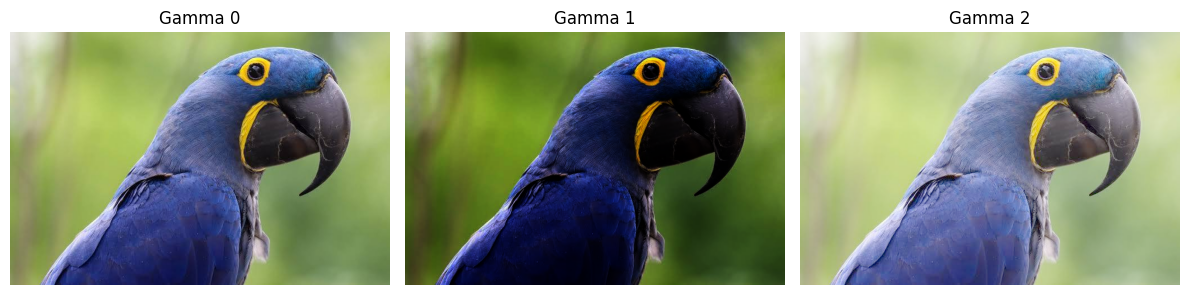

In [37]:
# Implement gamma_correction function here
import numpy as np

def gamma_correction(image, gamma):
    """
    :param image: np array (uint8, 0-255)
    :param gamma: >1 darker, <1 brighter
    :return: uint8 image
    """
    
    image_norm = image.astype(np.float32) / 255.0
    
    corrected = np.power(image_norm, gamma)
    
    res = np.clip(corrected * 255.0, 0, 255).astype(np.uint8)
    
    return res



file = "./images/parrot.jpeg"

img = cv2.imread(file)[:, :, ::-1]

images = [img] + [gamma_correction(img, val) for val in [2.1, 0.6]]

n = len(images)

plt.figure(figsize=(4*n, 4))

for i, img in enumerate(images):
    plt.subplot(1, n, i+1)  
    plt.imshow(img)
    plt.title(f"Gamma {i}")
    plt.axis("off")

plt.tight_layout()
plt.show()


### Challenge 1.2 – Gamma Curve Analysis

1. Generate intensity values r in range [0,1].
2. Plot gamma curves for at least 5 different gamma values.
3. Ensure all curves appear in one plot.

---


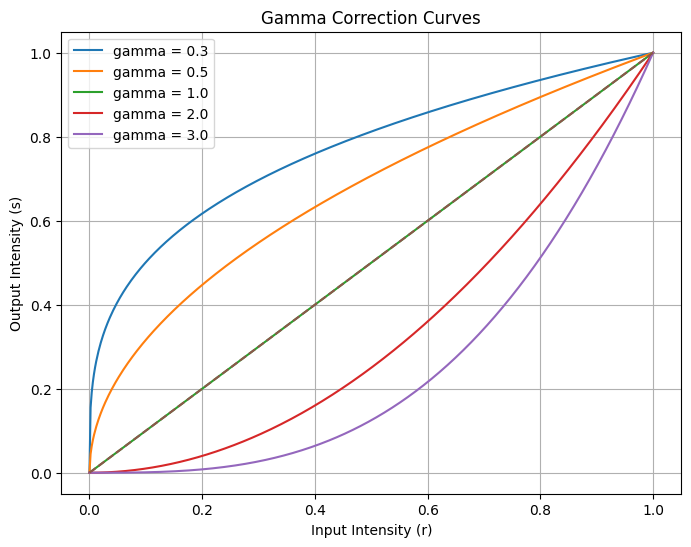

In [ ]:
# Plot gamma curves here

r = np.linspace(0, 1, 500)

gammas = [0.3, 0.5, 1.0, 2.0, 3.0]

plt.figure(figsize=(8, 6))

for gamma in gammas:
    s = r ** gamma
    plt.plot(r, s, label=f'gamma = {gamma}')

plt.plot(r, r, linestyle='--')

plt.title("Gamma Correction Curves")
plt.xlabel("Input Intensity (r)")
plt.ylabel("Output Intensity (s)")
plt.legend()
plt.grid(True)
plt.show()


### Challenge 1.3 – Comparative Study

Apply gamma values:
- 0.5
- 1.0
- 2.0

Display results in a structured layout.
Add titles clearly indicating gamma value.

---


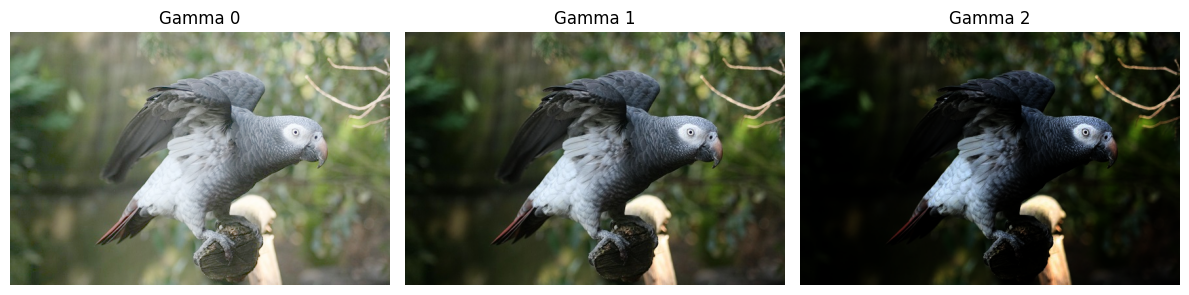

In [47]:
# Comparative gamma correction implementation
gammas = [0.5, 1.0, 2.0]

img2 = cv2.imread("./images/parrot3.jpg")[:, :, ::-1]

gamma_images = [gamma_correction(img2, val) for val in gammas]

n = len(gamma_images)

plt.figure(figsize=(4*n, 4))

for i, img in enumerate(gamma_images):
    plt.subplot(1, n, i+1)  
    plt.imshow(img)
    plt.title(f"Gamma {i}")
    plt.axis("off")

plt.tight_layout()
plt.show()


# Part 2 – Basic Intensity Transformations

### Challenge 2.1 – Image Negative

Create an image negative function without using built-in shortcuts.

Formula must be implemented manually.

---


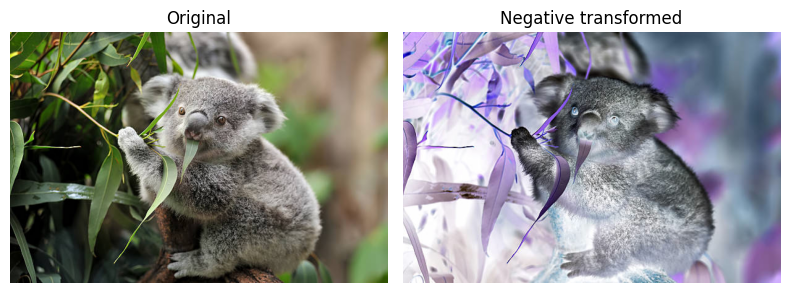

In [74]:
# Implement image negative transformation
img3 = cv2.imread("./images/kuala.jpg")[:,:, ::-1]

def intensify_img(img):
    """
    R' = 255 - R
    G' = 255 - G
    B' = 255 - B
    """
    img = np.clip(img, 0, 255).astype(np.uint8)
    res =  np.stack([255 - img[:, :, i] for i in range(3)], axis=2)
    return res

images = [img3] + [intensify_img(img3)]

n = len(images)

plt.figure(figsize=(4*n, 4))

for i, img in enumerate(images):
    plt.subplot(1, n, i+1)  
    plt.imshow(img)
    if i == 0:
        plt.title('Original')
    else:
        plt.title("Negative transformed")
    plt.axis("off")

plt.tight_layout()
plt.show()


### Challenge 2.2 – Intensity Range Mapping

Set pixel intensity range [A, B] to white (255).

Requirements:
- Accept A and B as parameters.
- Leave other pixels unchanged.
- Display before and after.

---


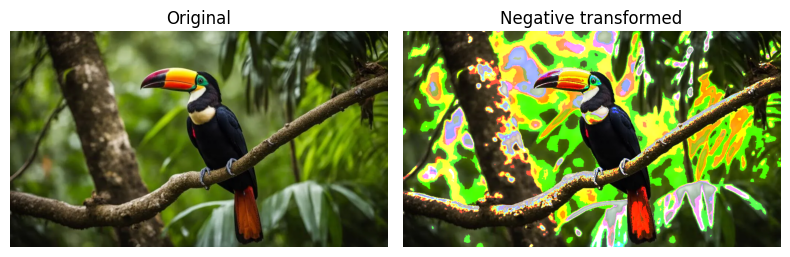

In [81]:
# Implement intensity range mapping
def intensity_range_mapping(img, A, B):

    img_mapped = img.copy()  

    mask = (img_mapped >= A) & (img_mapped <= B)
    img_mapped[mask] = 255

    return img_mapped

img4 = cv2.imread("./images/bird.webp")[:, :, ::-1]


images = [img4] + [intensity_range_mapping(img4, 100, 150)]

n = len(images)

plt.figure(figsize=(4*n, 4))

for i, img in enumerate(images):
    plt.subplot(1, n, i+1)  
    plt.imshow(img)
    if i == 0:
        plt.title('Original')
    else:
        plt.title("Negative transformed")
    plt.axis("off")

plt.tight_layout()
plt.show()


### Challenge 2.3 – Integrated Enhancement

Create a pipeline that:
1. Reads image
2. Applies gamma correction
3. Applies intensity mapping
4. Displays final enhanced image

---


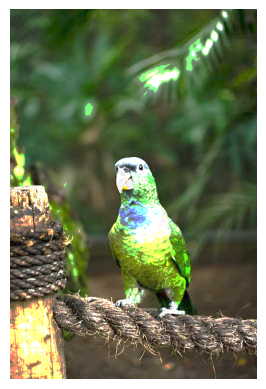

In [104]:
# Build full enhancement pipeline
def img_pipeline(img_path, gamma, A, B, plot: bool = True) -> None:
    """
    :param img_path: folder path
    :param gamma: 1<brither, 1>darker
    :param A, B: mapping values
    :param plot: display the image
    :returns: None
    """

    # 1. image reading
    procces1 = cv2.imread(img_path)[:, :, ::-1]
    
    # 2. applying gamma correction
    procces2 = gamma_correction(procces1, gamma)

    # 3. applying the intensity mapping
    res = intensity_range_mapping(procces2, A, B)
    
    # 4. ploting the final image
    if plot:
        plt.imshow(res)
        plt.axis("off")
        plt.show()
    

img_pipeline(img_path="./images/bird2.jpeg", gamma=0.5, A=150, B=220)


# Part 3 – Advanced Optimization Challenge

### Challenge 3.1 – Performance & Robustness

Improve your functions by:

- Adding input validation
- Handling grayscale and RGB images
- Avoiding redundant computations
- Structuring reusable functions

---

### Final Task

Create one clean final script that performs:
- Gamma analysis
- Negative transformation
- Intensity mapping
- Final comparison visualization

---


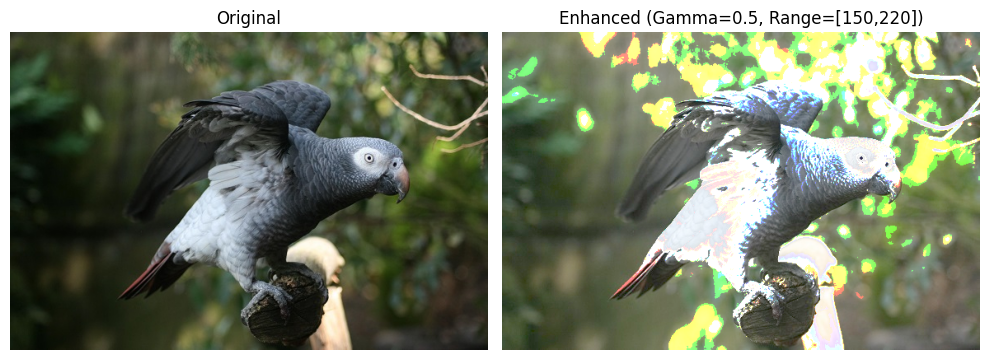

In [111]:
# Challenge 3:
def gamma_correction(img: np.ndarray, gamma: float) -> np.ndarray:
    """
    apply gamma correction to an image (grayscale or RGB)
    :param img: np.ndarray, image in [0,255]
    :param gamma: >1 darker, <1 brighter
    :return: gamma-corrected image, uint8
    """
    if not isinstance(img, np.ndarray):
        raise ValueError("Input image must be a numpy array")
    if gamma <= 0:
        raise ValueError("Gamma must be positive")
    
    img_float = img.astype(np.float32) / 255.0
    img_corrected = np.power(img_float, gamma)
    img_corrected = np.clip(img_corrected * 255, 0, 255).astype(np.uint8)
    
    return img_corrected


def intensity_range_mapping(img: np.ndarray, A: int, B: int) -> np.ndarray:
    """
    Map intensity range [A,B] to white (255), leave others unchanged
    Supports grayscale and RGB
    """
    if not isinstance(img, np.ndarray):
        raise ValueError("Input image must be a numpy array")
    if not (0 <= A <= B <= 255):
        raise ValueError("A and B must satisfy 0 <= A <= B <= 255")
    
    img_mapped = img.copy()
    
    if img.ndim == 2:
        mask = (img_mapped >= A) & (img_mapped <= B)
        img_mapped[mask] = 255
        
    elif img.ndim == 3 and img.shape[2] == 3:
        mask = (img_mapped >= A) & (img_mapped <= B)
        img_mapped[mask] = 255
        
    else:
        raise ValueError("Image must be 2D (grayscale) or 3D (RGB)")
    
    return img_mapped


def img_pipeline(img_path: str, gamma: float, A: int, B: int, plot: bool = True) -> np.ndarray:
    """
    Full enhancement pipeline:
    1. Read image (RGB)
    2. Gamma correction
    3. Intensity mapping
    4. Display final enhanced image (optional)
    :returns: enhanced image
    """
    if not isinstance(img_path, str):
        raise ValueError("img_path must be a string")
    
    img = cv2.imread(img_path)
    if img is None:
        raise FileNotFoundError(f"Image not found at {img_path}")
    
    if img.ndim == 3:
        img = img[:, :, ::-1]
    
    img_gamma = gamma_correction(img, gamma)
    
    img_enhanced = intensity_range_mapping(img_gamma, A, B)
    
    if plot:
        plt.figure(figsize=(10, 5))
        plt.subplot(1, 2, 1)
        plt.imshow(img)
        plt.title("Original")
        plt.axis("off")
        
        plt.subplot(1, 2, 2)
        plt.imshow(img_enhanced)
        plt.title(f"Enhanced (Gamma={gamma}, Range=[{A},{B}])")
        plt.axis("off")
        plt.tight_layout()
        plt.show()
    
    return img_enhanced


_ = img_pipeline(img_path="./images/parrot3.jpg", gamma=0.5, A=150, B=220)

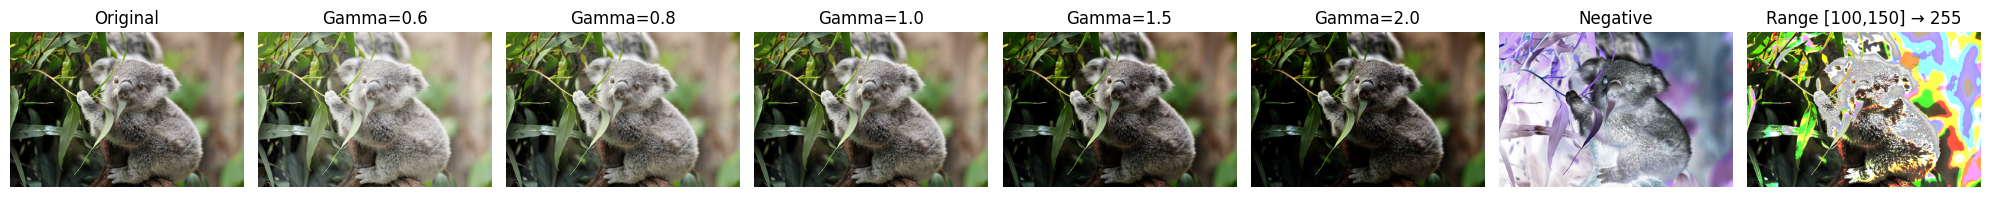

In [ ]:
# FINAL TASK
# Image Processing Functions
def gamma_correction(img: np.ndarray, gamma: float) -> np.ndarray:
    """Apply gamma correction to grayscale or RGB image."""
    img_float = img.astype(np.float32) / 255.0
    img_gamma = np.power(img_float, gamma)
    return np.clip(img_gamma * 255, 0, 255).astype(np.uint8)


def negative_image(img: np.ndarray) -> np.ndarray:
    """Compute negative of grayscale or RGB image."""
    return 255 - img


def intensity_range_mapping(img: np.ndarray, A: int, B: int) -> np.ndarray:
    """Map pixel intensity range [A,B] to white (255)."""
    img_mapped = img.copy()
    if img.ndim == 2:  
        mask = (img_mapped >= A) & (img_mapped <= B)
        img_mapped[mask] = 255
    elif img.ndim == 3 and img.shape[2] == 3:  
        mask = (img_mapped >= A) & (img_mapped <= B)
        img_mapped[mask] = 255
    else:
        raise ValueError("Image must be grayscale or RGB")
    return img_mapped



def image_enhancement_pipeline(img_path: str,
                               gamma_values=[0.6, 0.8, 1.0, 1.5, 2.0],
                               neg: bool = True,
                               intensity_range=(100, 150),
                               plot: bool = True):
    """
    Full enhancement pipeline:
    1. Gamma analysis
    2. Negative transformation
    3. Intensity range mapping
    4. Display original, enhanced, negative, and range-mapped
    """
    
    img = cv2.imread(img_path)
    if img is None:
        raise FileNotFoundError(f"Image not found at {img_path}")
    if img.ndim == 3:
        img = img[:, :, ::-1]  

    gamma_images = [gamma_correction(img, g) for g in gamma_values]

    img_negative = negative_image(img) if neg else None

    A, B = intensity_range
    img_mapped = intensity_range_mapping(img, A, B)

    if plot:
        n_gamma = len(gamma_values)
        plt.figure(figsize=(4*n_gamma, 4))

        plt.subplot(1, n_gamma+3, 1)
        plt.imshow(img)
        plt.title("Original")
        plt.axis("off")

        for i, (g_img, g_val) in enumerate(zip(gamma_images, gamma_values)):
            plt.subplot(1, n_gamma+3, i+2)
            plt.imshow(g_img)
            plt.title(f"Gamma={g_val}")
            plt.axis("off")

        if neg:
            plt.subplot(1, n_gamma+3, n_gamma+2)
            plt.imshow(img_negative)
            plt.title("Negative")
            plt.axis("off")

        plt.subplot(1, n_gamma+3, n_gamma+3)
        plt.imshow(img_mapped)
        plt.title(f"Range [{A},{B}] → 255")
        plt.axis("off")

        plt.tight_layout()
        plt.show()

    return {
        "original": img,
        "gamma": gamma_images,
        "negative": img_negative,
        "intensity_mapped": img_mapped
    }



results = image_enhancement_pipeline(
    img_path="./images/kuala.jpg",
    gamma_values=[0.6, 0.8, 1.0, 1.5, 2.0],
    neg=True,
    intensity_range=(100, 150),
    plot=True
)